# Olist AI/ML Based Customer Retention Platform

## Objective

This notebook performs exploratory data analysis (EDA) on the Olist Brazilian E-Commerce dataset.

The goal is to determine whether the dataset supports building a customer churn prediction system.

The analysis focuses on:

- Customer purchasing behaviour
- Repeat purchase patterns
- Customer lifetime value
- Revenue distribution
- Data availability for feature engineering

The findings from this notebook will guide:
- Database schema design
- ETL pipeline development
- Machine learning feature engineering

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Standard Library
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

### Data Import

In [10]:
PROJECT_ROOT = Path("../")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)


In [13]:
def load_csv(file_path: Path) -> pd.DataFrame:
    """
    Load a CSV file into a pandas DataFrame.

    Parameters
    ----------
    file_path : Path
        Path to CSV file.

    Returns
    -------
    pd.DataFrame
    """

    print(f"\nLoading {file_path.name}...")

    df = pd.read_csv(file_path)

    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    return df

In [14]:
customers = load_csv(
    RAW_DATA_DIR / "olist_customers_dataset.csv"
)

orders = load_csv(
    RAW_DATA_DIR / "olist_orders_dataset.csv"
)

order_items = load_csv(
    RAW_DATA_DIR / "olist_order_items_dataset.csv"
)

payments = load_csv(
    RAW_DATA_DIR / "olist_order_payments_dataset.csv"
)

reviews = load_csv(
    RAW_DATA_DIR / "olist_order_reviews_dataset.csv"
)

products = load_csv(
    RAW_DATA_DIR / "olist_products_dataset.csv"
)

sellers = load_csv(
    RAW_DATA_DIR / "olist_sellers_dataset.csv"
)

geolocation = load_csv(
    RAW_DATA_DIR / "olist_geolocation_dataset.csv"
)

translation = load_csv(
    RAW_DATA_DIR / "product_category_name_translation.csv"
)


Loading olist_customers_dataset.csv...
Rows: 99,441
Columns: 5

Loading olist_orders_dataset.csv...
Rows: 99,441
Columns: 8

Loading olist_order_items_dataset.csv...
Rows: 112,650
Columns: 7

Loading olist_order_payments_dataset.csv...
Rows: 103,886
Columns: 5

Loading olist_order_reviews_dataset.csv...
Rows: 99,224
Columns: 7

Loading olist_products_dataset.csv...
Rows: 32,951
Columns: 9

Loading olist_sellers_dataset.csv...
Rows: 3,095
Columns: 4

Loading olist_geolocation_dataset.csv...
Rows: 1,000,163
Columns: 5

Loading product_category_name_translation.csv...
Rows: 71
Columns: 2


### Dataset Summary

In [44]:
def dataset_summary(df: pd.DataFrame, name: str):
    """
    Print high-level dataset information.
    """

    print()
    print("=" * 20)
    print(name)

    print(f"Shape: {df.shape}")
    print(f"Info:")
    df.info()


In [45]:
dataset_summary(customers, "Customers")
dataset_summary(orders, "Orders")
dataset_summary(order_items, "Order Items")
dataset_summary(payments, "Payments")
dataset_summary(reviews, "Reviews")
dataset_summary(products, "Products")
dataset_summary(sellers, "Sellers")
dataset_summary(geolocation, "Geolocation")
dataset_summary(translation, "Translation")



Customers
Shape: (99441, 5)
Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB

Orders
Shape: (99441, 8)
Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp  

### Dataset Preview using head()

In [27]:
def preview(df: pd.DataFrame, name: str, rows: int = 5):

    print()
    print("=" * 20)
    print(name)

    display(df.head(rows))

In [28]:
preview(customers, "Customers")
preview(orders, "Orders")
preview(order_items, "Order Items")
preview(payments, "Payments")
preview(reviews, "Reviews")
preview(products, "Products")
preview(sellers, "Sellers")
preview(geolocation, "Geolocation")
preview(translation, "Translation")



Customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Order Items


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



Geolocation


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



Translation


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Check Missing Values
#### Orders, Reviews, Products has missing values based on .info() just now

In [29]:
def missing_report(df: pd.DataFrame, name: str):

    missing = df.isna().sum()

    missing = missing[missing > 0]

    print()
    print("=" * 20)
    print(name)

    if missing.empty:

        print("No Missing Values")

    else:

        report = pd.DataFrame({

            "Missing Count": missing,

            "Missing Percentage": (
                missing / len(df) * 100
            ).round(2)

        })

        display(report.sort_values(
            "Missing Percentage",
            ascending=False
        ))

In [31]:
missing_report(orders, "Orders")
missing_report(products, "Products")
missing_report(reviews, "Reviews")


Orders


,Missing Count,Missing Percentage
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16



Products


,Missing Count,Missing Percentage
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01



Reviews


,Missing Count,Missing Percentage
review_comment_title,87656,88.34
review_comment_message,58247,58.70


### Check Duplication

In [ ]:
def duplicate_report(df: pd.DataFrame, name: str):

    duplicates = df.duplicated().sum()

    print(f"{name}")

    print(f"Duplicate Rows: {duplicates:,}")

In [35]:
duplicate_report(customers, "Customers")
duplicate_report(orders, "Orders")
duplicate_report(order_items, "Order Items")
duplicate_report(payments, "Payments")
duplicate_report(reviews, "Reviews")
duplicate_report(products, "Products")
duplicate_report(sellers, "Sellers")
duplicate_report(geolocation, "Geolocation")
duplicate_report(translation, "Translation")


Customers
Duplicate Rows: 0
Orders
Duplicate Rows: 0
Order Items
Duplicate Rows: 0
Payments
Duplicate Rows: 0
Reviews
Duplicate Rows: 0
Products
Duplicate Rows: 0
Sellers
Duplicate Rows: 0
Geolocation
Duplicate Rows: 261,831
Translation
Duplicate Rows: 0


### Datetime Column Transformation for Visualization

In [19]:
# Transform date columns to datetime format
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]


for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col]
    )

### Distribution of Order Status

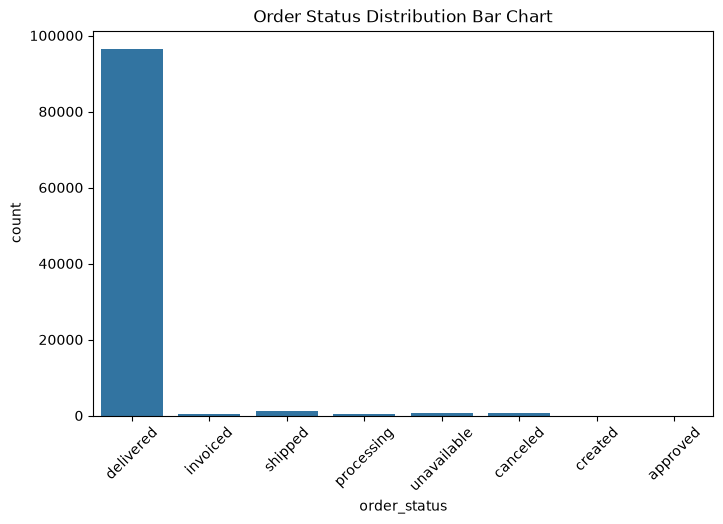

In [20]:
orders["order_status"].value_counts()

plt.figure(figsize=(8,5))

sns.countplot(
    data=orders,
    x="order_status"
)

plt.xticks(rotation=45)
plt.title(
    "Order Status Distribution Bar Chart"
)

plt.show()

### Customer Distribution

In [21]:
# Unique customers count
unique_customers = customers[
    "customer_unique_id"
].nunique()

unique_customers

96096

### Repeat Purchase Analysis

In [22]:
customer_orders = orders.merge(customers, 
                               on = 'customer_id',
                               how = 'left')

purchase_freq = (customer_orders.groupby('customer_unique_id')
                 .size()
                 .reset_index(name='purchase_count'))

purchase_freq.describe()

,purchase_count
count,96096.000000
mean,1.034809
std,0.214384
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,17.000000


### Revenue Analysis

In [23]:
order_revenue = (order_items.groupby('order_id')['price']
                 .sum()
                 .reset_index(name='revenue_of_order'))

order_revenue.head()

,order_id,revenue_of_order
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [24]:
orders_revenue = orders.merge(order_revenue, 
                                    on='order_id', 
                                    how='left')

orders_revenue.rename(columns={"price": "order_value"}, 
                            inplace=True)

orders_revenue.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,revenue_of_order
count,99441,99281,97658,96476,99441,98666.000000
mean,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111,137.754076
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.850000
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00,45.900000
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,86.900000
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00,149.900000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,13440.000000
std,NaN,NaN,NaN,NaN,NaN,210.645145


In [25]:
orders_revenue.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,revenue_of_order
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90


### Customer Lifetime Value (CLV) Exploration

In [26]:
customer_revenue = (customer_orders.merge(orders_revenue,
                                         on='order_id',
                                         how='left')
                                  .groupby('customer_unique_id')['revenue_of_order']
                                  .sum()
                                  .reset_index(name='total_revenue'))
customer_revenue.head()

,customer_unique_id,total_revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90
2,0000f46a3911fa3c0805444483337064,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,25.99
4,0004aac84e0df4da2b147fca70cf8255,180.00


In [27]:
customer_revenue.describe()

,total_revenue
count,96096.000000
mean,141.438184
std,217.215904
min,0.000000
25%,45.990000
50%,89.000000
75%,154.000000
max,13440.000000


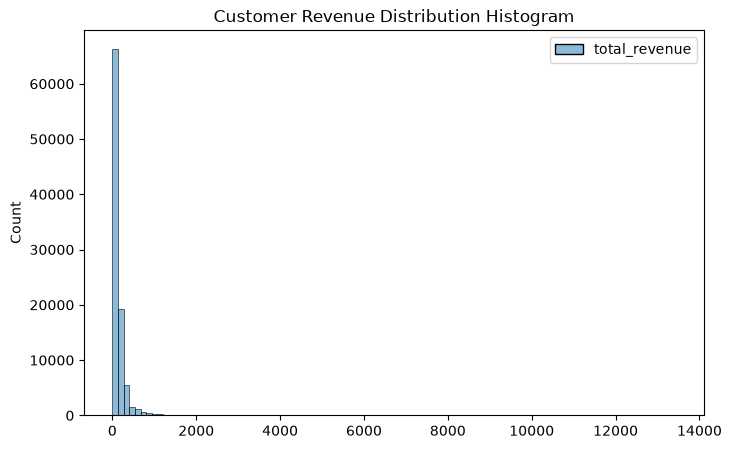

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_revenue,
    bins=100
)

plt.title(
    "Customer Revenue Distribution Histogram"
)

plt.show()

### Delivery Days Analysis

In [29]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

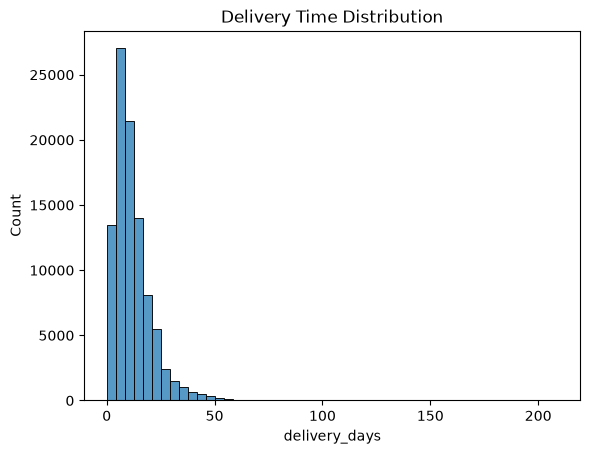

In [ ]:
sns.histplot(
    orders["delivery_days"],
    bins=50
)

plt.title(
    "Delivery Time Distribution Histogram"
)

plt.show()

### Review Score Analysis

In [35]:
review_counts = reviews["review_score"].value_counts()
review_counts

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

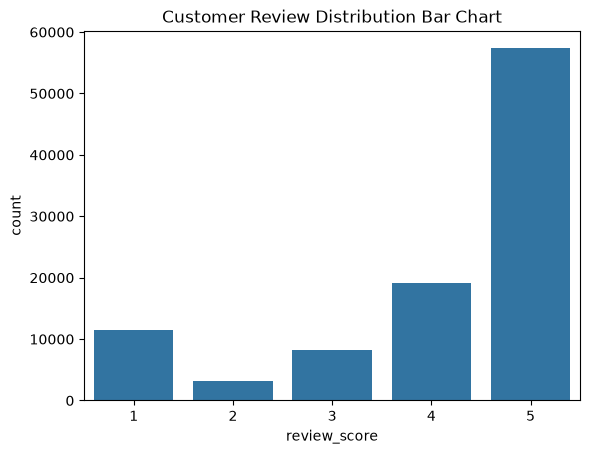

In [42]:
sns.countplot(
    data=reviews,
    x="review_score"
)

plt.title(
    "Customer Review Distribution Bar Chart"
)

plt.show()

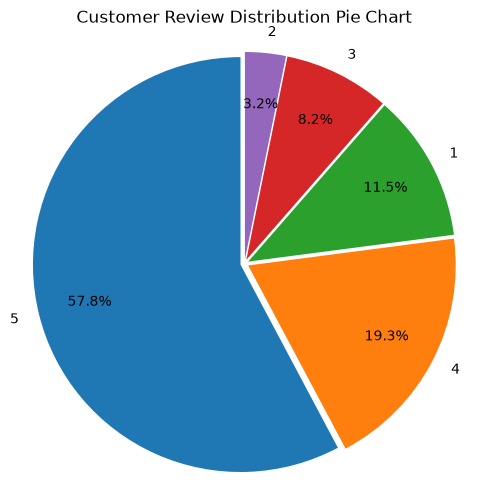

In [ ]:
plt.figure(figsize=(6, 6))

plt.pie(
    review_counts,
    labels=review_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.02] * len(review_counts),
    pctdistance=0.75
)

plt.title("Customer Review Distribution Pie Chart")
plt.axis("equal")  
plt.show()

## Initial Feature Engineering Ideas

Based on EDA, potential customer-level features include:

### Purchase Behaviour

- Total number of orders
- Total spending
- Average order value
- Days since last purchase

### Product Behaviour

- Number of unique products purchased
- Number of product categories purchased

### Customer Experience

- Average review score
- Delivery delay frequency

### Payment Behaviour

- Average installment count
- Preferred payment method

### Target Variable

Possible churn definition:

Customer is considered churned if no transaction occurs within X days after their previous purchase.

# Conclusion

The exploratory analysis shows that:

1. The Olist dataset contains sufficient information for customer behaviour analysis.

2. Repeat purchase frequency is relatively low, making traditional retention analysis challenging.

3. However, customer-level behavioural features can be engineered to predict future inactivity.

4. The dataset supports:
- RFM segmentation
- Customer Lifetime Value analysis
- Churn prediction
- Personalized retention recommendation using LLMs